# Zaawansowane techniki ensemble learning

In [71]:
#Wczytanie danych

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [72]:
#Bagging z użyciem Random Forest}

from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy_bagg = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy_bagg)

Accuracy: 0.9649122807017544


In [73]:
#Boosting z użyciem XGBoost}

# from xgboost import XGBClassifier
# xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
# xgb.fit(X_train, y_train)
# y_pred = xgb.predict(X_test)
# print("Accuracy:", accuracy_score(y_test, y_pred))

from sklearn.ensemble import GradientBoostingClassifier

xgb = GradientBoostingClassifier(n_estimators=150, random_state=42)
xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)
accuracy_boost = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy_boost)

Accuracy: 0.956140350877193


In [74]:
n_estimators_list = [3, 5, 10]

print("Tuning parametru n_estimators:")

for estimators in n_estimators_list:
    model = GradientBoostingClassifier(n_estimators=estimators, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print(f"Liczba drzew (n_estimators) = {estimators:3d}  -->  Accuracy: {acc:.4f}")

Tuning parametru n_estimators:
Liczba drzew (n_estimators) =   3  -->  Accuracy: 0.9386
Liczba drzew (n_estimators) =   5  -->  Accuracy: 0.9561
Liczba drzew (n_estimators) =  10  -->  Accuracy: 0.9561


In [75]:
max_depth_list = [3, 5, 10]

print("Tuning parametru max_depth:")

for max_depth in max_depth_list:
    model = GradientBoostingClassifier(max_depth=max_depth, n_estimators=5, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print(f"Maksymalna głębokość drzew (max_depth) = {max_depth:3d}  -->  Accuracy: {acc:.4f}")

Tuning parametru max_depth:
Maksymalna głębokość drzew (max_depth) =   3  -->  Accuracy: 0.9561
Maksymalna głębokość drzew (max_depth) =   5  -->  Accuracy: 0.9474
Maksymalna głębokość drzew (max_depth) =  10  -->  Accuracy: 0.9386


In [76]:
learning_rate_list = [0.05, 0.1, 0.2]

print("Tuning parametru szybkość uczenia:")

for learning_rate in learning_rate_list:
    model = GradientBoostingClassifier(learning_rate=learning_rate, max_depth=3, n_estimators=5, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print(f"Szybkość uczenia (learning_rate) = {learning_rate}  -->  Accuracy: {acc:.4f}")

Tuning parametru szybkość uczenia:
Szybkość uczenia (learning_rate) = 0.05  -->  Accuracy: 0.9298
Szybkość uczenia (learning_rate) = 0.1  -->  Accuracy: 0.9561
Szybkość uczenia (learning_rate) = 0.2  -->  Accuracy: 0.9561


In [77]:
#Stacking

from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

estimators = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('svc', SVC(probability=True))
]

stack = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression())
stack.fit(X_train, y_train)
y_pred = stack.predict(X_test)
accuracy_stack = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy_stack)

Accuracy: 0.9736842105263158


In [78]:
#Stacking rozbudowany

from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

estimators = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('svc', SVC(probability=True)),
    ('knn', KNeighborsClassifier(n_neighbors=5))
]

stack = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression())
stack.fit(X_train, y_train)
y_pred = stack.predict(X_test)
accuracy_stack_ext = accuracy_score(y_test, y_pred)
print("Accuracy stacking- podstawowy:", accuracy_stack)
print("Accuracy stacking-rozbudowany:", accuracy_stack_ext)

Accuracy stacking- podstawowy: 0.9736842105263158
Accuracy stacking-rozbudowany: 0.9736842105263158


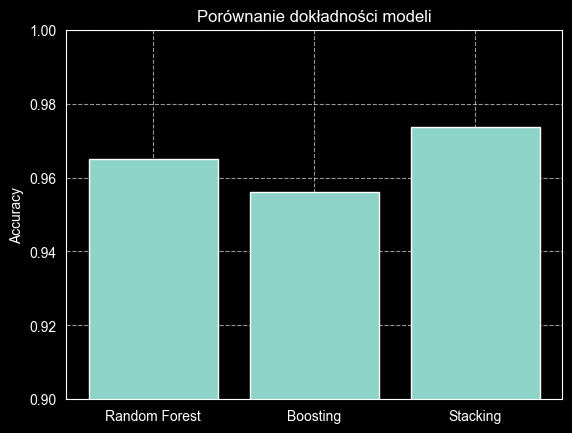

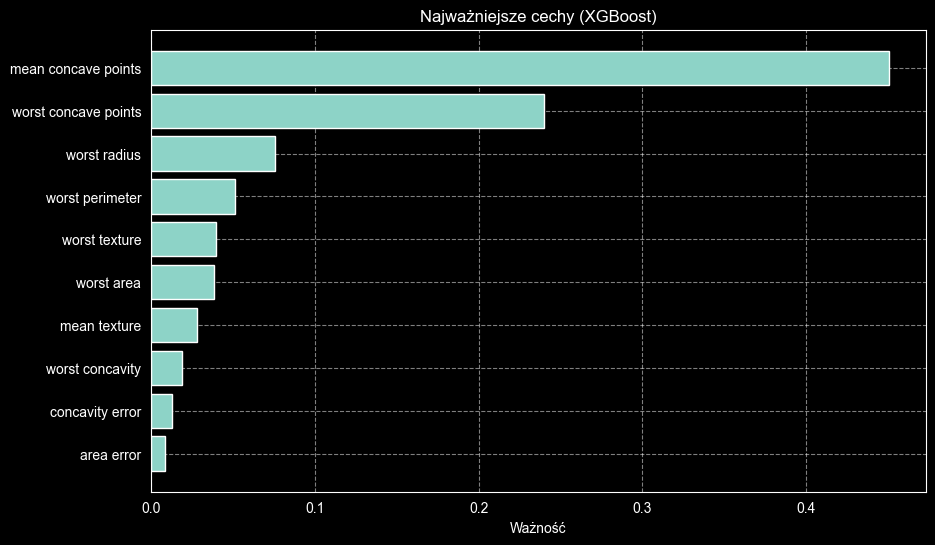

In [79]:
# Kod pomocniczy do analizy wyników

import matplotlib.pyplot as plt
import numpy as np

models = ['Random Forest', 'Boosting', 'Stacking']
accuracies = [accuracy_bagg, accuracy_boost, accuracy_stack]

plt.bar(models, accuracies)
plt.ylabel('Accuracy')
plt.title('Porównanie dokładności modeli')
plt.ylim(0.9, 1.0)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Feature importance (dla XGBoost)
importances = xgb.feature_importances_
indices = np.argsort(importances)[-10:][::-1]  # top 10
features = load_breast_cancer().feature_names

plt.figure(figsize=(10, 6))
plt.title("Najważniejsze cechy (XGBoost)")
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Ważność')
plt.gca().invert_yaxis()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [83]:
# from sklearn.datasets import load_breast_cancer
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import accuracy_score
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.ensemble import GradientBoostingClassifier
# from sklearn.ensemble import StackingClassifier
# from sklearn.linear_model import LogisticRegression
# from sklearn.svm import SVC
from sklearn.datasets import load_wine

X, y = load_wine(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy_bagg_wine = accuracy_score(y_test, y_pred)
print("Accuracy:Random Forest", accuracy_bagg_wine)


xgb = GradientBoostingClassifier(n_estimators=100, random_state=42)
xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)
accuracy_boost_wine = accuracy_score(y_test, y_pred)
print("Accuracy:Gradient Boosting", accuracy_boost_wine)

estimators = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('svc', SVC(probability=True)),
    ('knn', KNeighborsClassifier(n_neighbors=5))
]

stack = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression())
stack.fit(X_train, y_train)
y_pred = stack.predict(X_test)
accuracy_stack_wine = accuracy_score(y_test, y_pred)
print("Accuracy:Stacking", accuracy_stack_wine)



Accuracy:Random Forest 1.0
Accuracy:Gradient Boosting 0.9444444444444444
Accuracy:Stacking 1.0


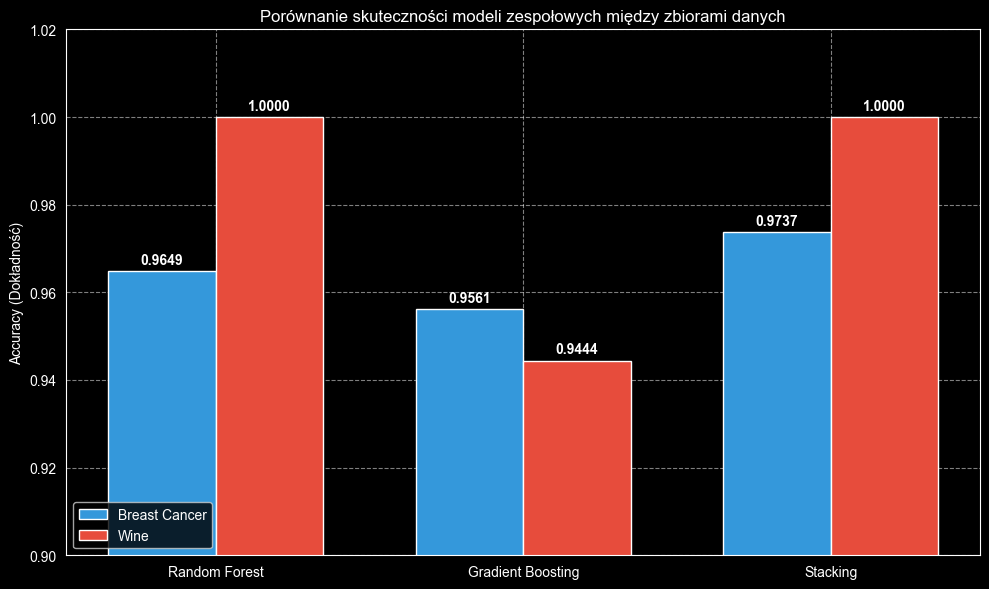

In [82]:
import numpy as np
import matplotlib.pyplot as plt

models = ['Random Forest', 'Gradient Boosting', 'Stacking']

bc_accuracies = [accuracy_bagg, accuracy_boost, accuracy_stack_ext]
wine_accuracies = [accuracy_bagg_wine, accuracy_boost_wine, accuracy_stack_wine]

x = np.arange(len(models))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 6))
bars_bc = ax.bar(x - width/2, bc_accuracies, width, label='Breast Cancer', color='#3498db')
bars_wine = ax.bar(x + width/2, wine_accuracies, width, label='Wine', color='#e74c3c')

ax.set_ylabel('Accuracy (Dokładność)')
ax.set_title('Porównanie skuteczności modeli zespołowych między zbiorami danych')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0.90, 1.02)
ax.legend(loc='lower left')
ax.grid(True, linestyle='--', alpha=0.5)


def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.4f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # Przesunięcie tekstu o 3 punkty w pionie
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold')

add_labels(bars_bc)
add_labels(bars_wine)

plt.tight_layout()
plt.show()